# Creating Plot Graphs 

In [10]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Load dataset
df = pd.read_csv("merged_citibike_weather_2022.csv", parse_dates=["date", "started_at", "ended_at"])

# Make sure trip_duration_minutes exists
if 'trip_duration_minutes' not in df.columns:
    df['trip_duration_minutes'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# Preview
df.head()

C:\Users\TypicalPancake\AppData\Local\Temp\ipykernel_1496\872557263.py:8: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("merged_citibike_weather_2022.csv", parse_dates=["date", "started_at", "ended_at"])


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,date,PRCP,TMAX,TMIN,trip_duration_minutes
0,BFD29218AB271154,electric_bike,2022-01-21 13:13:43.392,2022-01-21 13:22:31.463,West End Ave & W 107 St,7650.05,Mt Morris Park W & W 120 St,7685.14,40.802117,-73.968181,40.804038,-73.945925,member,2022-01-21,0.0,23.0,15.0,8.801183
1,7C953F2FD7BE1302,classic_bike,2022-01-10 11:30:54.162,2022-01-10 11:41:43.422,4 Ave & 3 St,4028.04,Boerum Pl\t& Pacific St,4488.09,40.673746,-73.985649,40.688489,-73.991160,member,2022-01-10,0.0,42.0,26.0,10.821000
2,95893ABD40CED4B8,electric_bike,2022-01-26 10:52:43.096,2022-01-26 11:06:35.227,1 Ave & E 62 St,6753.08,5 Ave & E 29 St,6248.06,40.761227,-73.960940,40.745168,-73.986831,member,2022-01-26,0.0,30.0,21.0,13.868850
3,F853B50772137378,classic_bike,2022-01-03 08:35:48.247,2022-01-03 09:10:50.475,2 Ave & E 96 St,7338.02,5 Ave & E 29 St,6248.06,40.783964,-73.947167,40.745168,-73.986831,member,2022-01-03,0.0,39.0,24.0,35.037133
4,7590ADF834797B4B,classic_bike,2022-01-22 14:14:23.043,2022-01-22 14:34:57.474,6 Ave & W 34 St,6364.1,5 Ave & E 29 St,6248.06,40.749640,-73.988050,40.745168,-73.986831,member,2022-01-22,0.0,30.0,14.0,20.573850


# Had to clean data was giving the merged set over 10 million rows. Pivoted the weather data set and made sure to have the same amount of rows as the merged citibike dataset. Was having duplicates expanding the dataset exponentially causing a big headache.

# Data Visualizations Plots, Columns, Line Charts

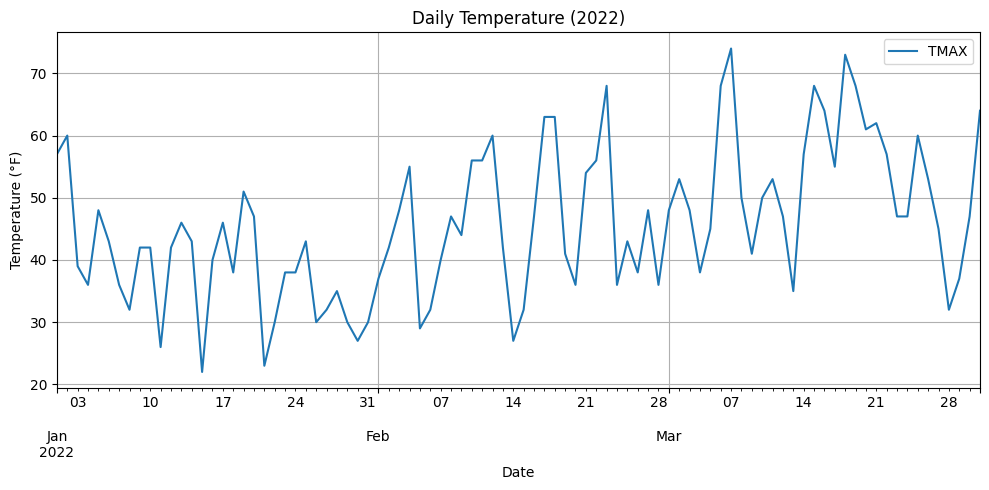

<Figure size 640x480 with 0 Axes>

In [26]:
# Line Plot "Temperature Over Time"
df_temp = df[['date', 'TMAX']].dropna().drop_duplicates()
df_temp = df_temp.sort_values('date')  # Ensure dates are in order

# Plot
df_temp.plot(x='date', y='TMAX', title='Daily Temperature (2022)', figsize=(10, 5))
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("Daily Temperature 2022")

In [20]:
# Drop rows with *any* NaN values
df_cleaned = df.dropna()

# Create trip count per day
trip_counts = df_cleaned.groupby('date').size().reset_index(name='trip_count')

# Extract TMAX per day
weather_df = df_cleaned[['date', 'TMAX']].drop_duplicates()

# Merge the two
merged_df = pd.merge(trip_counts, weather_df, on='date')

# Preview
merged_df.head()

,date,trip_count,TMAX
0,2022-01-01,20198,57.0
1,2022-01-02,42203,60.0
2,2022-01-03,32453,39.0
3,2022-01-04,35869,36.0
4,2022-01-05,33689,48.0


# Got rid of "NaN" rows to display accurate trip counts for my data set.

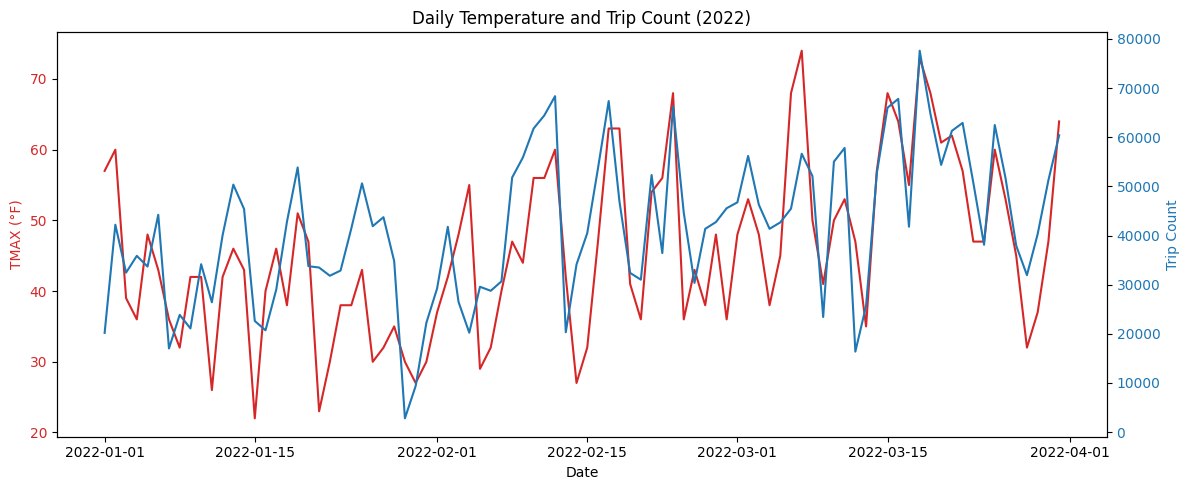

<Figure size 640x480 with 0 Axes>

In [27]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('Date')
ax1.set_ylabel('TMAX (°F)', color='tab:red')
ax1.plot(merged_df['date'], merged_df['TMAX'], color='tab:red', label='Temperature')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Trip Count', color='tab:blue')
ax2.plot(merged_df['date'], merged_df['trip_count'], color='tab:blue', label='Trip Count')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Daily Temperature and Trip Count (2022)')
plt.tight_layout()
plt.show()
plt.savefig("Daily Temperature and Trip Count 2022")

Utilized Matplotlib to visualize the daily temperature and trip count trent. 
1. A line plot of daily temperature using Pandas’ built-in `.plot()` method, which is a simple way to make charts.
2. A dual-axis plot for trip count and temperature. We used Matplotlib's object-oriented style (`fig`, `ax1`, `ax2`) so we could have two y-axes on the same chart. This helps compare two trends that use different units.

# Bonus Round

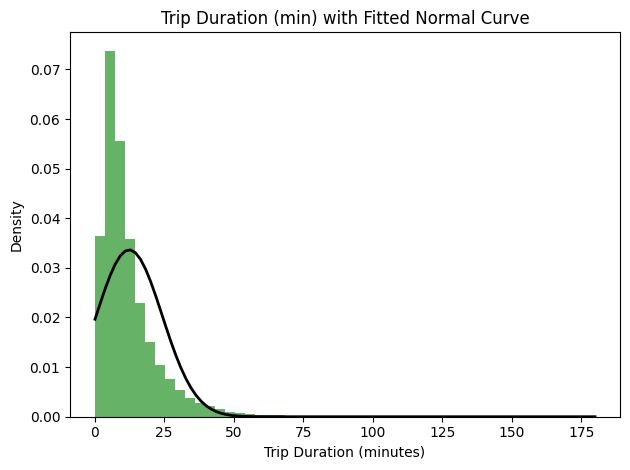

<Figure size 640x480 with 0 Axes>

In [28]:
duration = df['trip_duration_minutes'].dropna()
duration = duration[(duration > 0) & (duration < 180)]  # remove outliers

plt.hist(duration, bins=50, density=True, alpha=0.6, color='green')

mu, std = norm.fit(duration)
x = np.linspace(duration.min(), duration.max(), 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

plt.title('Trip Duration (min) with Fitted Normal Curve')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()
plt.savefig("Trip Duration Min With Fitted Normal Curve")

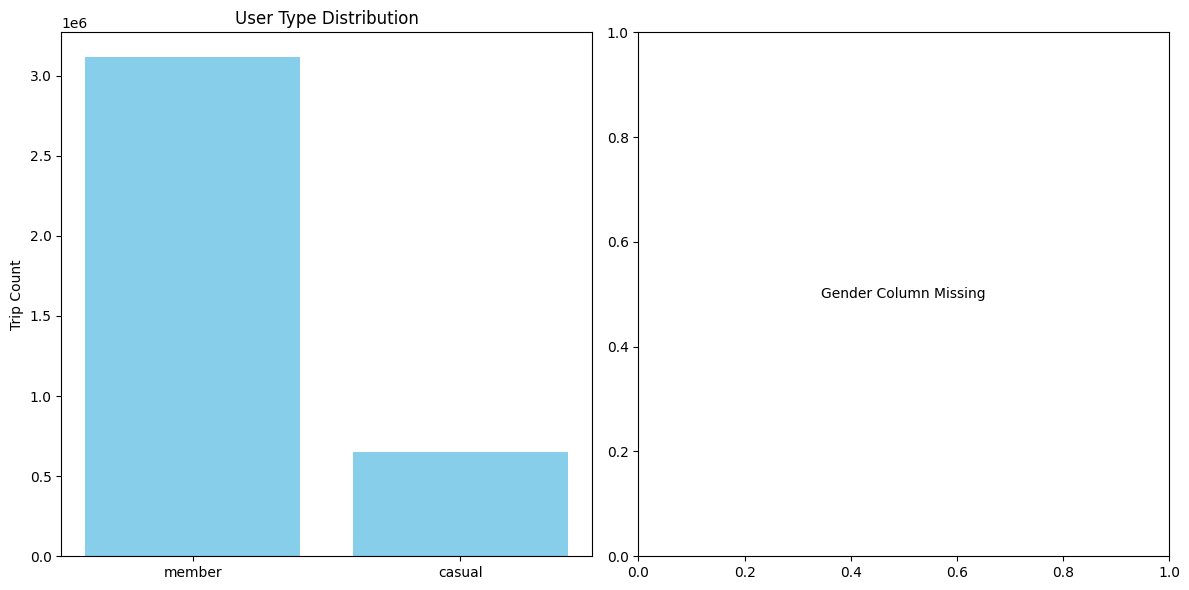

<Figure size 640x480 with 0 Axes>

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Bar chart: member type
if 'member_casual' in df.columns:
    user_counts = df['member_casual'].value_counts()
    ax1.bar(user_counts.index, user_counts.values, color='skyblue')
    ax1.set_title('User Type Distribution')
    ax1.set_ylabel('Trip Count')

# Pie chart: gender
if 'gender' in df.columns:
    gender_counts = df['gender'].dropna().value_counts()
    if not gender_counts.empty:
        ax2.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
        ax2.set_title('Gender Distribution')
    else:
        ax2.text(0.5, 0.5, 'No Gender Data Available', ha='center', va='center')
else:
    ax2.text(0.5, 0.5, 'Gender Column Missing', ha='center', va='center')

plt.tight_layout()
plt.show()
plt.savefig("User Type Distribution Bar & Invalid Gender Pie Chart")

# I did not have any data regarding the gender of the members so I could not fulfill pie chart request. 